In [322]:
import torch

device = "cuda" if torch.cuda.is_available() else "cpu"

RANDOM_SEED = 42

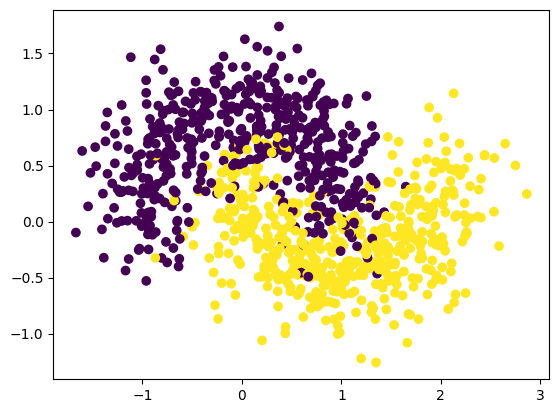

In [323]:
from sklearn.datasets import make_moons
import matplotlib.pyplot as plt

N_SAMPLES = 1000

X, y = make_moons(n_samples=N_SAMPLES, random_state=RANDOM_SEED, noise=0.3)

plt.scatter(X[:, 0], X[:, 1], c=y)

X, y = torch.from_numpy(X).type(torch.float), torch.from_numpy(y).type(torch.float)

In [324]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [325]:
from torch import nn

class MoonModeV0(nn.Module):
    
    def __init__(self, input_features, output_features, hidden_units = 10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
        
    def forward(self, x):
        return self.network(x)
    
model0 = MoonModeV0(input_features=2, output_features=1).to(device)
model0

MoonModeV0(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=10, bias=True)
    (5): ReLU()
    (6): Linear(in_features=10, out_features=1, bias=True)
  )
)

In [326]:
loss_fn = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(params=model0.parameters(), lr=0.1)

In [327]:
!pip -q install torchmetrics

In [328]:
from torchmetrics import Accuracy

acc_fn = Accuracy(task="multiclass", num_classes=2).to(device)

In [329]:
epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model0.train()
    
    y_logits = model0(X_train).squeeze()
    y_pred = torch.round(torch.sigmoid(y_logits))
    
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_pred, y_train.int())
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model0.eval()
    
    with torch.inference_mode():
        
        test_logits = model0(X_test).squeeze()
        test_pred = torch.round(torch.sigmoid(test_logits))
        
        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_pred, y_test.int())
        
    
    if epoch % 100:
        
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")

Epoch: 1 | Loss: 0.69315 | Accuracy: 0.50% | Test Loss: 0.69397 | Test Accuracy: 0.50%
Epoch: 2 | Loss: 0.69256 | Accuracy: 0.50% | Test Loss: 0.69342 | Test Accuracy: 0.50%
Epoch: 3 | Loss: 0.69199 | Accuracy: 0.50% | Test Loss: 0.69290 | Test Accuracy: 0.50%
Epoch: 4 | Loss: 0.69145 | Accuracy: 0.50% | Test Loss: 0.69240 | Test Accuracy: 0.50%
Epoch: 5 | Loss: 0.69092 | Accuracy: 0.50% | Test Loss: 0.69191 | Test Accuracy: 0.50%
Epoch: 6 | Loss: 0.69042 | Accuracy: 0.50% | Test Loss: 0.69145 | Test Accuracy: 0.50%
Epoch: 7 | Loss: 0.68993 | Accuracy: 0.50% | Test Loss: 0.69100 | Test Accuracy: 0.50%
Epoch: 8 | Loss: 0.68946 | Accuracy: 0.50% | Test Loss: 0.69056 | Test Accuracy: 0.50%
Epoch: 9 | Loss: 0.68900 | Accuracy: 0.50% | Test Loss: 0.69014 | Test Accuracy: 0.50%
Epoch: 10 | Loss: 0.68855 | Accuracy: 0.50% | Test Loss: 0.68972 | Test Accuracy: 0.50%
Epoch: 11 | Loss: 0.68811 | Accuracy: 0.50% | Test Loss: 0.68931 | Test Accuracy: 0.50%
Epoch: 12 | Loss: 0.68769 | Accuracy: 0.5

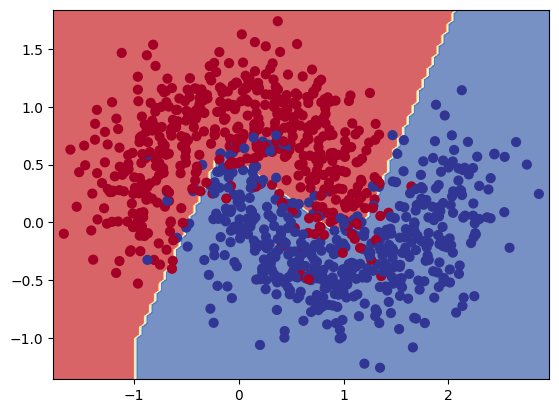

In [330]:
from helper_functions import plot_decision_boundary

plot_decision_boundary(model0, X, y)

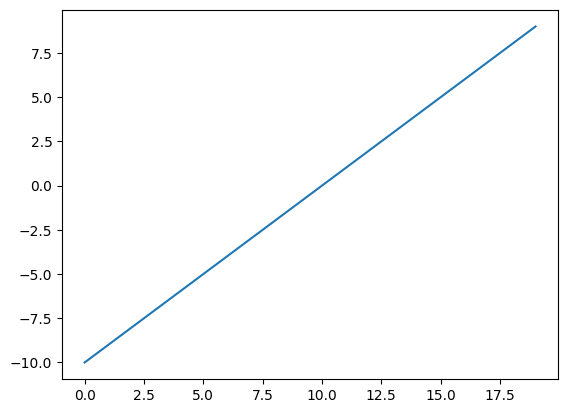

In [331]:
def tanh(x):
    
    return (torch.exp(x) - torch.exp(-x)) / (torch.exp(x) + torch.exp(-x))

A = torch.arange(-10, 10, 1)
plt.plot(A)

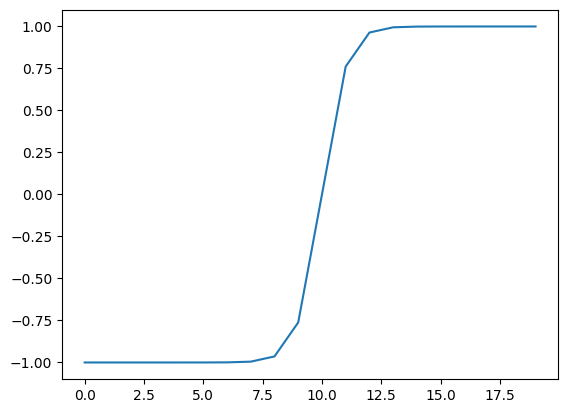

In [332]:
plt.plot(tanh(A))

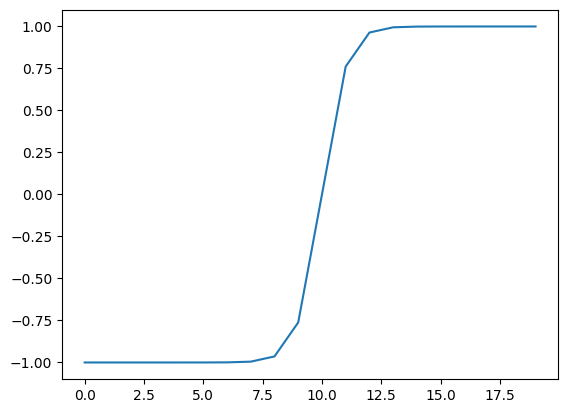

In [333]:
plt.plot(torch.tanh(A))

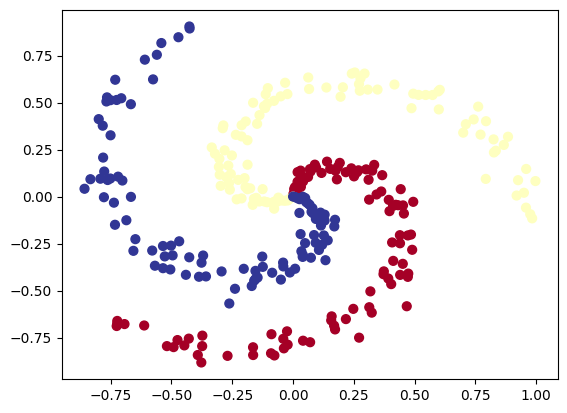

In [334]:
# From CS231n
import numpy as np
import matplotlib.pyplot as plt

np.random.seed(RANDOM_SEED)
N = 100 
D = 2 
K = 3 
X = np.zeros((N*K,D)) 
y = np.zeros(N*K, dtype='uint8') 

for j in range(K):
    ix = range(N*j,N*(j+1))
    r = np.linspace(0.0,1,N)
    t = np.linspace(j*4,(j+1)*4,N) + np.random.randn(N)*0.2
    X[ix] = np.c_[r*np.sin(t), r*np.cos(t)]
    y[ix] = j


plt.scatter(X[:, 0], X[:, 1], c=y, s=40, cmap=plt.cm.RdYlBu)
plt.show()

In [335]:
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.LongTensor)

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=RANDOM_SEED)

In [336]:
class SpiralModel0(nn.Module):
    
    def __init__(self, input_features, output_features, hidden_units=10):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(in_features=input_features, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=hidden_units),
            nn.ReLU(),
            nn.Linear(in_features=hidden_units, out_features=output_features)
        )
        
    def forward(self, x):
        return self.network(x)
    
model1 = SpiralModel0(input_features=D, output_features=K).to(device)
model1

SpiralModel0(
  (network): Sequential(
    (0): Linear(in_features=2, out_features=10, bias=True)
    (1): ReLU()
    (2): Linear(in_features=10, out_features=10, bias=True)
    (3): ReLU()
    (4): Linear(in_features=10, out_features=3, bias=True)
  )
)

In [337]:
loss_fn = nn.CrossEntropyLoss()
acc_fn = Accuracy(task="multiclass", num_classes=K).to(device)
optimizer = torch.optim.Adam(params=model1.parameters(), lr=0.01)

In [338]:
epochs = 1000

X_train, X_test = X_train.to(device), X_test.to(device)
y_train, y_test = y_train.to(device), y_test.to(device)

for epoch in range(epochs):
    
    model1.train()
    y_logits = model1(X_train)
    y_pred = torch.softmax(y_logits, dim=1).argmax(dim=1)
    
    loss = loss_fn(y_logits, y_train)
    acc = acc_fn(y_pred, y_train)
    
    optimizer.zero_grad()
    
    loss.backward()
    
    optimizer.step()
    
    model1.eval()
    
    with torch.inference_mode():
        
        test_logits = model1(X_test)
        test_pred = torch.softmax(test_logits, dim=1).argmax(dim=1)
        
        test_loss = loss_fn(test_logits, y_test)
        test_acc = acc_fn(test_pred, y_test)
        
    
    if epoch % 100:
        
        print(f"Epoch: {epoch} | Loss: {loss:.5f} | Accuracy: {acc:.2f}% | Test Loss: {test_loss:.5f} | Test Accuracy: {test_acc:.2f}%")
            

Epoch: 1 | Loss: 1.12645 | Accuracy: 0.32% | Test Loss: 1.11523 | Test Accuracy: 0.37%
Epoch: 2 | Loss: 1.12076 | Accuracy: 0.32% | Test Loss: 1.11018 | Test Accuracy: 0.37%
Epoch: 3 | Loss: 1.11524 | Accuracy: 0.32% | Test Loss: 1.10544 | Test Accuracy: 0.37%
Epoch: 4 | Loss: 1.11006 | Accuracy: 0.32% | Test Loss: 1.10090 | Test Accuracy: 0.37%
Epoch: 5 | Loss: 1.10506 | Accuracy: 0.32% | Test Loss: 1.09622 | Test Accuracy: 0.37%
Epoch: 6 | Loss: 1.10018 | Accuracy: 0.32% | Test Loss: 1.09151 | Test Accuracy: 0.37%
Epoch: 7 | Loss: 1.09546 | Accuracy: 0.32% | Test Loss: 1.08693 | Test Accuracy: 0.37%
Epoch: 8 | Loss: 1.09089 | Accuracy: 0.32% | Test Loss: 1.08240 | Test Accuracy: 0.37%
Epoch: 9 | Loss: 1.08641 | Accuracy: 0.32% | Test Loss: 1.07826 | Test Accuracy: 0.37%
Epoch: 10 | Loss: 1.08212 | Accuracy: 0.32% | Test Loss: 1.07408 | Test Accuracy: 0.37%
Epoch: 11 | Loss: 1.07797 | Accuracy: 0.32% | Test Loss: 1.06987 | Test Accuracy: 0.37%
Epoch: 12 | Loss: 1.07390 | Accuracy: 0.3

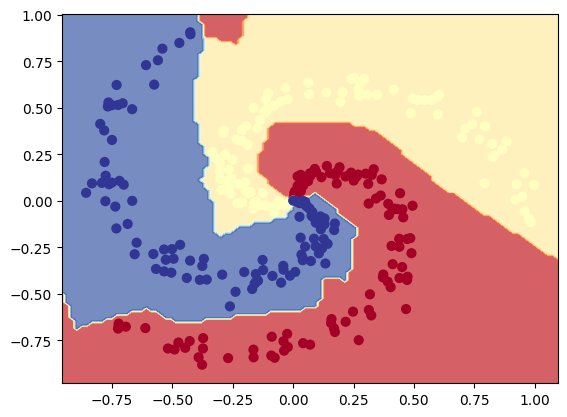

In [339]:
plot_decision_boundary(model1, X, y)